# Entrega 2 — Detecção de Duplicatas

**Ouvidoria Inteligente: Triagem Semântica de Manifestações Cidadãs**

O problema: a mesma reclamação chega escrita de formas diferentes ("asfalto esburacado" × "rua com buraco") e é tratada como duas. Este notebook faz quatro coisas:

1. Constrói a função `detectar_duplicatas(textos, limiar=0.85)`, que devolve todos os pares com similaridade de cosseno acima do limiar, calculada sobre embeddings.
2. Mostra a matriz de similaridade completa em heatmap.
3. Justifica a escolha do limiar.
4. Analisa os falsos positivos e os falsos negativos contra as duplicatas reais do conjunto.

> O gabarito das duplicatas reais está em `duplicatas_reais.json`: 6 pares, 15% das 40 manifestações.

In [1]:
import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from ouvidoria import (
    MODELO_PADRAO,
    avaliar_deteccao,
    carregar_duplicatas_reais,
    carregar_manifestacoes,
    carregar_modelo,
    detectar_duplicatas,
    gerar_embeddings,
    matriz_similaridade,
)

df = pd.DataFrame(carregar_manifestacoes())
ids, textos = df["id"].tolist(), df["texto"].tolist()
reais = carregar_duplicatas_reais()
modelo = carregar_modelo(MODELO_PADRAO)
print(f"{len(textos)} manifestações · {len(reais)} pares de duplicatas reais: {sorted(reais)}")

40 manifestações · 6 pares de duplicatas reais: [('M003', 'M017'), ('M008', 'M022'), ('M010', 'M036'), ('M011', 'M029'), ('M012', 'M028'), ('M019', 'M034')]


## 1) A função `detectar_duplicatas`

- **Entrada:** a lista de textos e o limiar, com padrão 0,85, como pede o enunciado. Um parâmetro opcional permite trocar o modelo.
- **Processo:** gera os embeddings normalizados com `paraphrase-multilingual-MiniLM-L12-v2`, calcula a similaridade de cosseno entre todos os pares (i < j) e fica com os que passam do limiar.
- **Saída:** a lista de pares `(i, j, similaridade)`, da maior para a menor similaridade.

In [2]:
print(inspect.getsource(detectar_duplicatas))

def detectar_duplicatas(textos: list[str], limiar: float = 0.85, modelo=None) -> list[tuple[int, int, float]]:
    """Todos os pares (i, j, similaridade), com i < j, cuja similaridade de cosseno passa do limiar.

    Os embeddings são os do modelo multilíngue (ou do `modelo` informado). A lista sai ordenada da
    maior para a menor similaridade.
    """
    sims = matriz_similaridade(gerar_embeddings(textos, modelo))
    pares = [
        (i, j, float(sims[i, j]))
        for i in range(len(textos))
        for j in range(i + 1, len(textos))
        if sims[i, j] > limiar
    ]
    return sorted(pares, key=lambda p: -p[2])



## 2) Matriz de similaridade completa

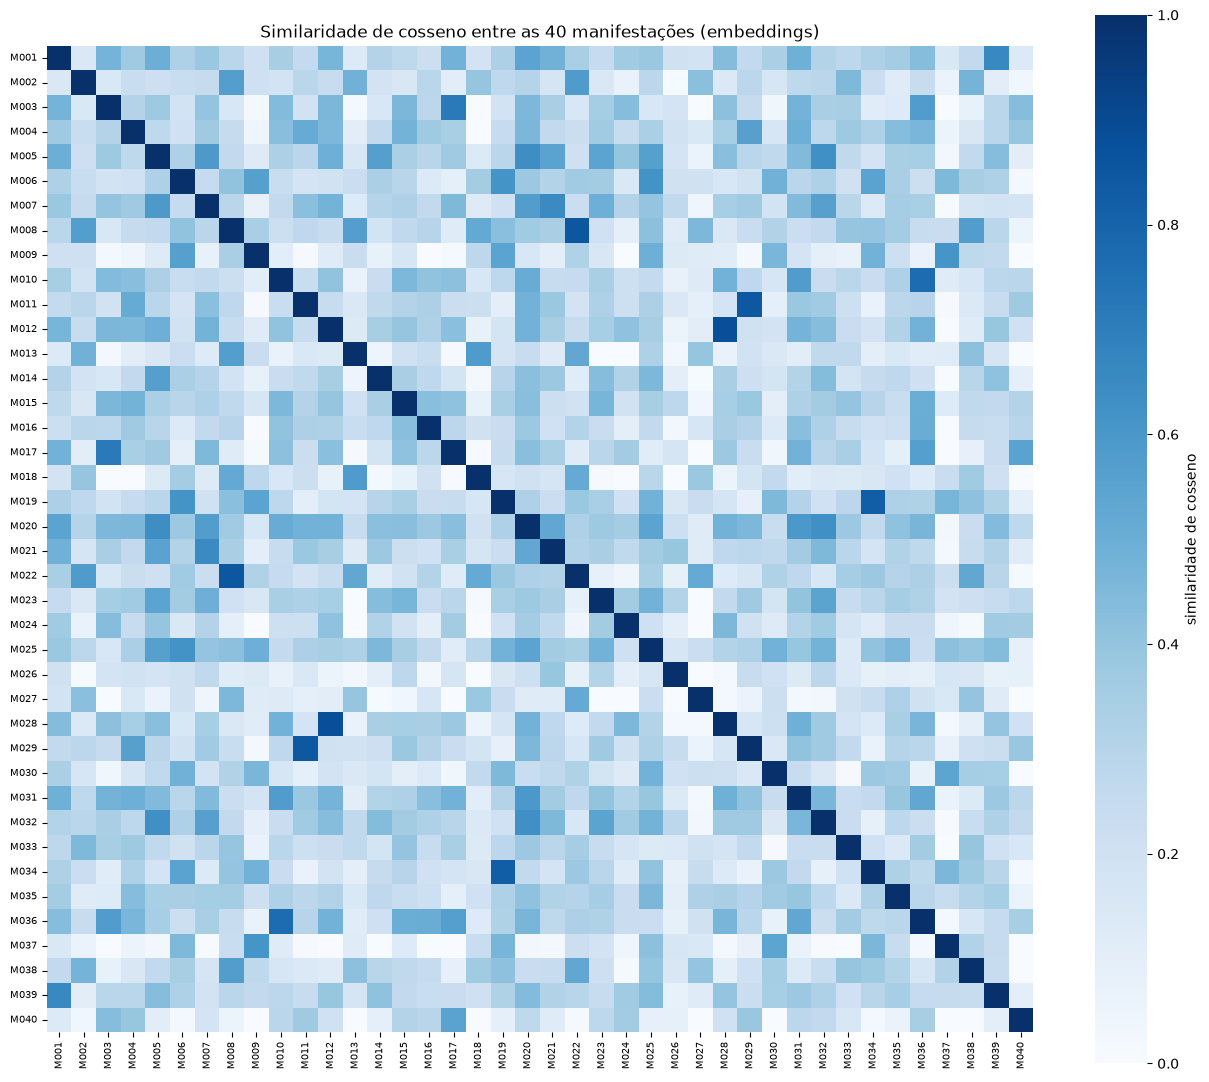

780 pares · média 0.268 · mediana 0.264 · máximo 0.883


In [3]:
S = matriz_similaridade(gerar_embeddings(textos, modelo))
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(pd.DataFrame(S, index=ids, columns=ids), cmap="Blues", vmin=0, vmax=1, square=True,
            cbar_kws={"label": "similaridade de cosseno"}, xticklabels=True, yticklabels=True, ax=ax)
ax.tick_params(labelsize=7)
ax.set_title("Similaridade de cosseno entre as 40 manifestações (embeddings)")
plt.tight_layout()
plt.show()

triangulo = S[np.triu_indices(len(S), 1)]
print(f"{triangulo.size} pares · média {triangulo.mean():.3f} · mediana {np.median(triangulo):.3f} · máximo {triangulo.max():.3f}")

## 3) Resultado com o limiar padrão (0,85)

In [4]:
def como_ids(pares):
    return {tuple(sorted((ids[i], ids[j]))) for i, j, _ in pares}


def tabela_pares(pares):
    return pd.DataFrame([
        {"Par": f"{ids[i]} × {ids[j]}", "Similaridade": round(s, 3),
         "Duplicata real?": "sim" if tuple(sorted((ids[i], ids[j]))) in reais else "não"}
        for i, j, s in pares
    ])


pares_085 = detectar_duplicatas(textos, modelo=modelo)  # limiar padrão = 0.85
aval_085 = avaliar_deteccao(como_ids(pares_085), reais)
print(f"Limiar 0,85 → {len(pares_085)} par(es) · VP={len(aval_085['vp'])} FP={len(aval_085['fp'])} FN={len(aval_085['fn'])}")
tabela_pares(pares_085)

Limiar 0,85 → 1 par(es) · VP=1 FP=0 FN=5


,Par,Similaridade,Duplicata real?
0,M012 × M028,0.883,sim


## 4) Escolha do limiar

Três candidatos foram comparados em toda a faixa:

- **o padrão 0,85**;
- **um limiar dinâmico** (percentil 90 da distribuição de similaridades, como sugere a seção 7 do enunciado);
- **uma varredura de 0,50 a 0,90**.

In [5]:
rotulo = {}
for i in range(len(ids)):
    for j in range(i + 1, len(ids)):
        rotulo[(ids[i], ids[j])] = S[i, j]
sim_dup = np.array([rotulo[p] for p in reais])
sim_nao = np.array([s for p, s in rotulo.items() if p not in reais])
percentil_90 = float(np.percentile(triangulo, 90))

linhas = []
for limiar in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, round(percentil_90, 3)]:
    a = avaliar_deteccao(como_ids(detectar_duplicatas(textos, limiar, modelo)), reais)
    linhas.append({"Limiar": limiar, "VP": len(a["vp"]), "FP": len(a["fp"]), "FN": len(a["fn"]),
                   "Precisão": round(a["precisao"], 2), "Revocação": round(a["revocacao"], 2), "F1": round(a["f1"], 2)})
varredura = pd.DataFrame(linhas).sort_values("Limiar").reset_index(drop=True)
print(f"Percentil 90 das similaridades = {percentil_90:.3f}")
print(f"Duplicatas reais: de {sim_dup.min():.3f} a {sim_dup.max():.3f} · maior não duplicata: {sim_nao.max():.3f}")
varredura

Percentil 90 das similaridades = 0.471
Duplicatas reais: de 0.715 a 0.883 · maior não duplicata: 0.660


,Limiar,VP,FP,FN,Precisão,Revocação,F1
0,0.471,6,72,0,0.08,1.00,0.14
1,0.500,6,44,0,0.12,1.00,0.21
2,0.550,6,27,0,0.18,1.00,0.31
3,0.600,6,8,0,0.43,1.00,0.60
4,0.650,6,1,0,0.86,1.00,0.92
5,0.700,6,0,0,1.00,1.00,1.00
6,0.750,5,0,1,1.00,0.83,0.91
7,0.800,4,0,2,1.00,0.67,0.80
8,0.850,1,0,5,1.00,0.17,0.29
9,0.900,0,0,6,0.00,0.00,0.00


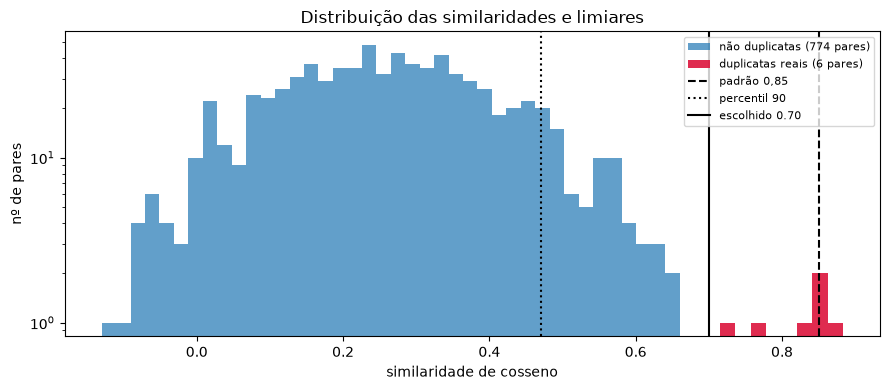

In [6]:
LIMIAR = 0.70

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(sim_nao, bins=40, alpha=0.7, label=f"não duplicatas ({sim_nao.size} pares)")
ax.hist(sim_dup, bins=8, alpha=0.9, color="crimson", label=f"duplicatas reais ({sim_dup.size} pares)")
for valor, estilo, nome in [(0.85, "--", "padrão 0,85"), (percentil_90, ":", "percentil 90"), (LIMIAR, "-", f"escolhido {LIMIAR:.2f}")]:
    ax.axvline(valor, color="black", linestyle=estilo, label=nome)
ax.set_xlabel("similaridade de cosseno")
ax.set_ylabel("nº de pares")
ax.set_yscale("log")
ax.legend(fontsize=8)
ax.set_title("Distribuição das similaridades e limiares")
plt.tight_layout()
plt.show()

### Justificativa: limiar = 0,70

- **0,85 é estrito demais.** O modelo dá às paráfrases do mesmo problema notas entre ≈ 0,72 e ≈ 0,88. Com 0,85 só o par mais literal é detectado (1 de 6), e voltamos ao problema original das duplicatas não detectadas.
- **O percentil 90 (≈ 0,47) é permissivo demais.** Por construção, ele marca 10% de todos os 780 pares, cerca de 78, e quase todos são manifestações do *mesmo tema* (duas queixas de escola, duas de lixo), não do *mesmo problema*. É útil para agrupar temas, não para achar duplicatas.
- **0,70 separa os dois grupos.** A maior não duplicata fica em ≈ 0,66 e a menor duplicata real em ≈ 0,72. Com 0,70 as 6 duplicatas são detectadas sem nenhum falso positivo (precisão = revocação = 1). Na varredura, 0,65 já traz um falso positivo e 0,75 perde uma duplicata.
- **Ressalva:** a folga é estreita (≈ 0,02 para o lado das duplicatas) e o limiar foi calibrado neste conjunto. Com mais dados, a calibração deve ser refeita. Na operação, o mais seguro é usar 0,70 para *sugerir* duplicatas a um atendente e não para fundir manifestações automaticamente.

In [7]:
pares_escolhidos = detectar_duplicatas(textos, limiar=LIMIAR, modelo=modelo)
aval_escolhido = avaliar_deteccao(como_ids(pares_escolhidos), reais)
print(f"Limiar {LIMIAR} → VP={len(aval_escolhido['vp'])} FP={len(aval_escolhido['fp'])} FN={len(aval_escolhido['fn'])}")
tabela_pares(pares_escolhidos)

Limiar 0.7 → VP=6 FP=0 FN=0


,Par,Similaridade,Duplicata real?
0,M012 × M028,0.883,sim
1,M008 × M022,0.848,sim
2,M011 × M029,0.845,sim
3,M019 × M034,0.823,sim
4,M010 × M036,0.767,sim
5,M003 × M017,0.715,sim


## 5) Falsos positivos e falsos negativos

In [8]:
pos = {m: k for k, m in enumerate(ids)}


def resumo(a, b):
    return f"{a} × {b} (sim = {S[pos[a], pos[b]]:.3f})\n   {a}: {textos[pos[a]][:95]}…\n   {b}: {textos[pos[b]][:95]}…"


print("FALSOS NEGATIVOS com o limiar padrão 0,85:")
for a, b in sorted(aval_085["fn"]):
    print(" •", resumo(a, b))

print(f"\nCom o limiar {LIMIAR}: FP = {sorted(aval_escolhido['fp']) or 'nenhum'} · FN = {sorted(aval_escolhido['fn']) or 'nenhum'}")

print("\nNão duplicatas mais próximas (viram FALSOS POSITIVOS se o limiar baixar para ≈ 0,60):")
mais_proximas = sorted(((s, p) for p, s in rotulo.items() if p not in reais), reverse=True)[:6]
for s, (a, b) in mais_proximas:
    print(" •", resumo(a, b))

FALSOS NEGATIVOS com o limiar padrão 0,85:
 • M003 × M017 (sim = 0.715)
   M003: Tem um buraco enorme na Av. Brasil, perto do cruzamento com a Rua Sete de Setembro. Os carros d…
   M017: O asfalto todo esburacado da avenida principal, na altura da Sete de Setembro, já derrubou um m…
 • M008 × M022 (sim = 0.848)
   M008: Posto de saúde sem médico: a unidade do bairro São José está sem clínico geral há mais de um mê…
   M022: Falta atendimento no PSF do São José. Desde o mês passado não aparece doutor, a recepcionista m…
 • M010 × M036 (sim = 0.767)
   M010: Os semáforos do cruzamento da Av. Epitácio Pessoa com a Rua Maranhão estão desligados há três d…
   M036: O sinal de trânsito da esquina da Epitácio Pessoa com a Maranhão parou de funcionar e cada moto…
 • M011 × M029 (sim = 0.845)
   M011: Um grupo usa a Praça da Liberdade para vender drogas durante a madrugada, e os moradores têm me…
   M029: Tráfico de drogas na Praça da Liberdade toda noite. As famílias do entorno estão com medo 

### Análise

**Falsos negativos (com 0,85).** As 5 duplicatas perdidas são paráfrases com vocabulário quase todo diferente:
- “buraco enorme na Av. Brasil” × “asfalto todo esburacado da avenida principal”, com ≈ 0,72, o par mais difícil;
- “semáforos desligados” × “sinal de trânsito parou de funcionar”;
- “vender drogas” × “tráfico de drogas”;
- “transporte escolar não passou” × “ônibus não apareceu”;
- “posto de saúde sem médico” × “falta atendimento no PSF”.

O modelo aproxima esses textos (0,72 a 0,85), mas não o bastante para passar de 0,85. A parte que não coincide pesa: um texto fala do acidente com moto e o outro do recapeamento, e o embedding representa o texto inteiro, não só o problema.

**Falsos positivos (candidatos, se o limiar baixar).** As não duplicatas mais próximas mostram dois padrões:
1. **Mesmo tema, problema diferente.** Calçada quebrada × escadaria sem corrimão (acessibilidade para idosos); terreno com lixo × coleta de lixo que não passa; escola sem merenda × escola sem ventilador. Um limiar baixo confunde *tema* com *ocorrência*.
2. **Textos longos parecidos entre si.** Os relatos longos (alagamento, arrombamentos, queimadas) ficam próximos uns dos outros (≈ 0,63), mesmo tratando de problemas distintos. A estrutura de denúncia formal (“já abrimos protocolo”, “pedimos providências”) domina o vetor. Comparar trechos (chunks, Entrega 3) ou resumos reduziria esse efeito.

**Conclusão.** Com 0,70 o detector acerta as 6 duplicatas deste conjunto sem falsos positivos. Os casos-limite indicam que o limiar deve ser recalibrado com mais dados e que a decisão final deve passar por um atendente.